In [207]:
import os
from pathlib import Path

# ── Anchor working directory ───────────────────────────────────────────────
THIS_NOTEBOOK = Path('data_modeling.ipynb').resolve()
PROJECT_ROOT  = THIS_NOTEBOOK.parent
os.chdir(PROJECT_ROOT)
print(f'Working directory set to: {PROJECT_ROOT}')

# ── Guard: check wrangling outputs exist ──────────────────────────────────
REQUIRED = [
    'data/processed/analysis_ready.csv',
    'data/processed/meeting_metrics.csv',
]
missing = [p for p in REQUIRED if not Path(p).exists()]
if missing:
    raise FileNotFoundError(
        f'\n\nMissing upstream files — run data_wrangling.ipynb first:\n'
        + '\n'.join(f'  ✗ {p}' for p in missing)
    )
print('All upstream files found safe to continue')


Working directory set to: /Users/rahul/Documents/IDS/Project_main/CAP5771_Meeting-Transcript-Analyzer/code
All upstream files found safe to continue


# Milestone 2 — Data Modeling
**Project:** Meeting Transcript Efficiency Analyzer  
**Course:** CAP5771 – Intro to Data Science  

**Input:** `data/processed/analysis_ready.csv`  
**Goals:**
1. **Model A** — Multi-class classifier: predict utterance label (*decision / action / discussion*)
2. **Model B** — Meeting-level clustering: group meetings by efficiency profile
3. Evaluate both models and save outputs for the dashboard

## 1. Load Data

In [208]:
import pandas as pd
import numpy as np
import os
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv('data/processed/analysis_ready.csv')
df_meetings = pd.read_csv('data/processed/meeting_metrics.csv')

print(f'Utterances : {len(df):,}')
print(f'Meetings   : {len(df_meetings)}')
print(f'Label dist :\n{df["label"].value_counts()}')

Utterances : 134,242
Meetings   : 171
Label dist :
label
discussion    132019
action          2033
decision         190
Name: count, dtype: int64


## 2. Model A — Utterance-level Classifier

**Task:** Given the cleaned text of an utterance, predict its label.  
**Strategy:** TF-IDF features → Logistic Regression (fast, interpretable).  
**Evaluation:** 5-fold stratified cross-validation to handle class imbalance.

In [209]:
# Feature / target
X_text = df['text_clean'].fillna('')
y      = df['label']

# Class sizes
print('Class distribution:')
print(y.value_counts(normalize=True).round(3))

Class distribution:
label
discussion    0.983
action        0.015
decision      0.001
Name: proportion, dtype: float64


In [210]:
# Pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=15_000,
        sublinear_tf=True,
        min_df=2
    )),
    ('clf', LogisticRegression(
        C=1.0,
        class_weight='balanced',   # handles class imbalance
        max_iter=500,
        solver='lbfgs',
    ))
])

# 5-fold stratified CV — yields out-of-fold predictions for the entire dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X_text, y, cv=cv, n_jobs=-1)

print('=== 5-Fold Cross-Validation Results ===')
print(classification_report(y, y_pred_cv, digits=3))

=== 5-Fold Cross-Validation Results ===
              precision    recall  f1-score   support

      action      0.651     0.952     0.773      2033
    decision      0.470     0.868     0.610       190
  discussion      0.999     0.991     0.995    132019

    accuracy                          0.990    134242
   macro avg      0.707     0.937     0.793    134242
weighted avg      0.993     0.990     0.991    134242



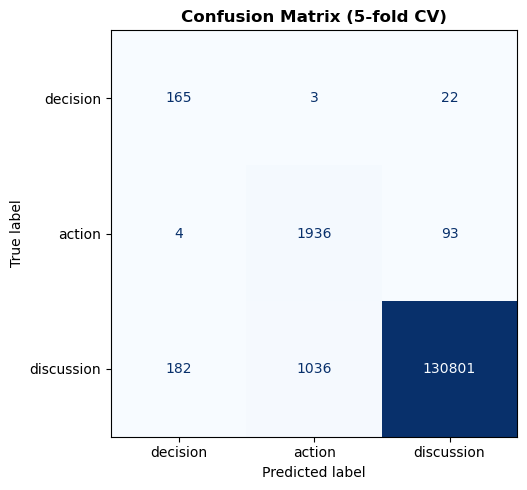

Saved: outputs/confusion_matrix.png


In [211]:
#  Confusion matrix
cm = confusion_matrix(y, y_pred_cv, labels=['decision','action','discussion'])
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(cm, display_labels=['decision','action','discussion'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix (5-fold CV)', fontweight='bold')
plt.tight_layout()
os.makedirs('outputs', exist_ok=True)
plt.savefig('outputs/confusion_matrix.png', dpi=120)
plt.show()
print('Saved: outputs/confusion_matrix.png')

In [212]:
# Fit final model on all data & save
pipeline.fit(X_text, y)

os.makedirs('models', exist_ok=True)
joblib.dump(pipeline, 'models/utterance_classifier.pkl')
print('Model saved: models/utterance_classifier.pkl')

# Save CV predictions back to the dataframe for analysis
df['predicted_label'] = y_pred_cv
df['correct'] = (df['label'] == df['predicted_label']).astype(int)

# Save error analysis file
df[df['correct'] == 0][['meeting_id','text_clean','label','predicted_label']]\
    .sample(min(200, (df['correct']==0).sum()), random_state=42)\
    .to_csv('outputs/error_analysis.csv', index=False)
print('Error sample saved: outputs/error_analysis.csv')

Model saved: models/utterance_classifier.pkl
Error sample saved: outputs/error_analysis.csv


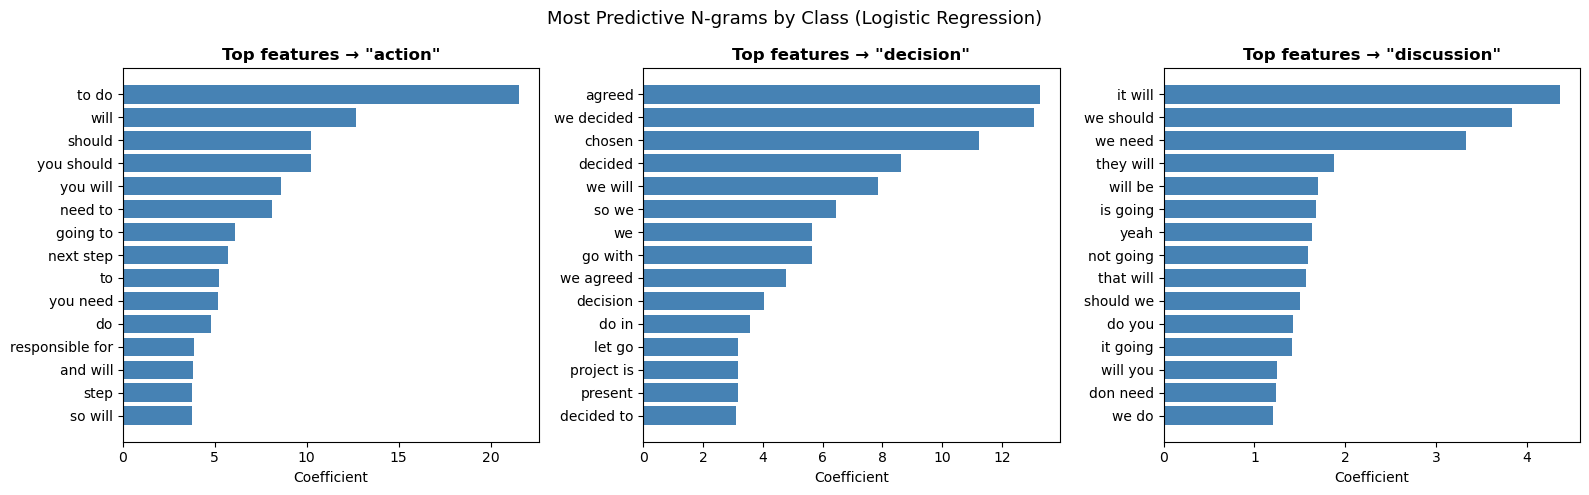

Saved: outputs/feature_importance.png


In [213]:
# Top features per class
tfidf   = pipeline.named_steps['tfidf']
lr      = pipeline.named_steps['clf']
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, cls, coef in zip(axes, lr.classes_, lr.coef_):
    top_idx = np.argsort(coef)[-15:][::-1]
    ax.barh(feature_names[top_idx][::-1], coef[top_idx][::-1], color='steelblue')
    ax.set_title(f'Top features → "{cls}"', fontweight='bold')
    ax.set_xlabel('Coefficient')
plt.suptitle('Most Predictive N-grams by Class (Logistic Regression)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/feature_importance.png', dpi=120)
plt.show()
print('Saved: outputs/feature_importance.png')

## 3. Model B — Meeting Efficiency Clustering

**Task:** Identify natural groups of meetings based on efficiency metrics.  
**Strategy:** K-Means on `[decision_density, action_density, redundancy_score, action_clarity]`  
**Evaluation:** Elbow curve + silhouette score.

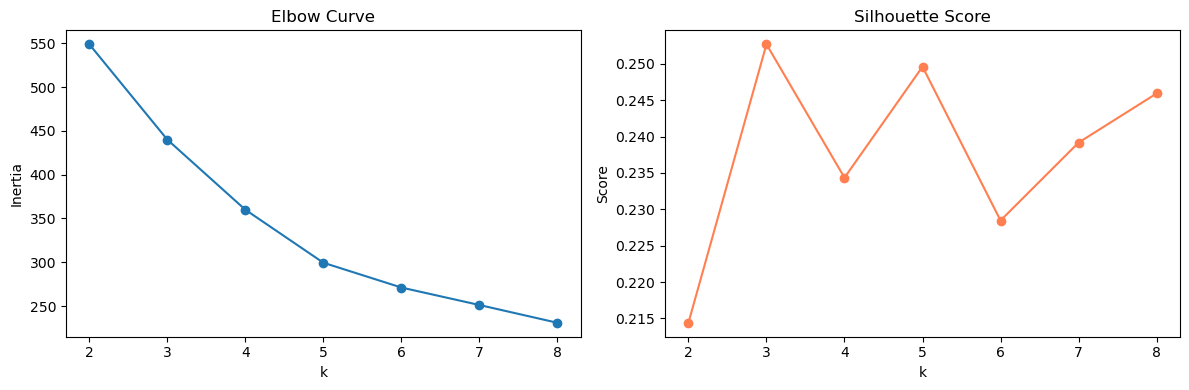

Best k by silhouette: 3 (score=0.253)


In [214]:
from sklearn.metrics import silhouette_score

cluster_features = ['decision_density', 'action_density',
                    'redundancy_score', 'action_clarity']
X_meet = df_meetings[cluster_features].fillna(0).values
X_meet_scaled = StandardScaler().fit_transform(X_meet)

# Elbow & silhouette
inertias, silhouettes = [], []
K_range = range(2, 9)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_meet_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_meet_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, marker='o')
ax1.set_title('Elbow Curve'); ax1.set_xlabel('k'); ax1.set_ylabel('Inertia')
ax2.plot(list(K_range), silhouettes, marker='o', color='coral')
ax2.set_title('Silhouette Score'); ax2.set_xlabel('k'); ax2.set_ylabel('Score')
plt.tight_layout()
plt.savefig('outputs/kmeans_selection.png', dpi=120)
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f'Best k by silhouette: {best_k} (score={max(silhouettes):.3f})')

In [215]:
# Fit final K-Means
K_FINAL = best_k
scaler  = StandardScaler()
X_scaled_final = scaler.fit_transform(X_meet)

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_meetings['cluster'] = km_final.fit_predict(X_scaled_final)

# Human-readable cluster labels (sorted by efficiency_score)
cluster_eff = df_meetings.groupby('cluster')['efficiency_score'].mean().sort_values(ascending=False)
rank_labels = {cid: lbl for cid, lbl in zip(cluster_eff.index,
               ['Highly Efficient','Moderately Efficient',
                'Low Efficiency','Very Low Efficiency'][:K_FINAL])}
df_meetings['cluster_label'] = df_meetings['cluster'].map(rank_labels)

print('Cluster distribution:')
print(df_meetings['cluster_label'].value_counts())
print('\nCluster mean metrics:')
print(df_meetings.groupby('cluster_label')[cluster_features + ['efficiency_score']].mean().round(3))

Cluster distribution:
cluster_label
Low Efficiency          97
Highly Efficient        42
Moderately Efficient    32
Name: count, dtype: int64

Cluster mean metrics:
                      decision_density  action_density  redundancy_score  \
cluster_label                                                              
Highly Efficient                 0.000           0.026             0.143   
Low Efficiency                   0.001           0.013             0.215   
Moderately Efficient             0.005           0.015             0.145   

                      action_clarity  efficiency_score  
cluster_label                                           
Highly Efficient               0.410             0.265  
Low Efficiency                 0.178             0.240  
Moderately Efficient           0.208             0.263  


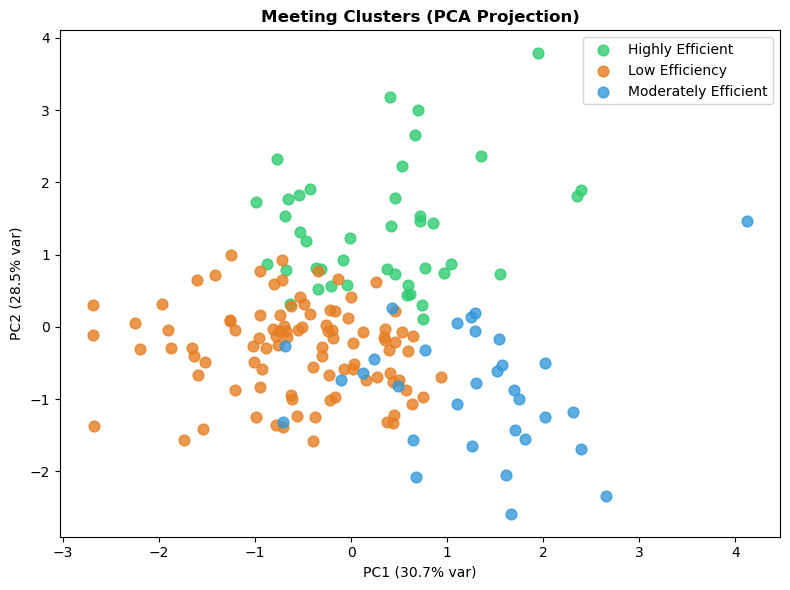

In [216]:
# PCA scatter for visualization
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled_final)
df_meetings['pca_x'] = coords[:, 0]
df_meetings['pca_y'] = coords[:, 1]

colors = {'Highly Efficient': '#2ecc71',
          'Moderately Efficient': '#3498db',
          'Low Efficiency': '#e67e22',
          'Very Low Efficiency': '#e74c3c'}

fig, ax = plt.subplots(figsize=(8, 6))
for lbl, grp in df_meetings.groupby('cluster_label'):
    ax.scatter(grp['pca_x'], grp['pca_y'], label=lbl,
               color=colors.get(lbl, 'grey'), s=60, alpha=0.8)
ax.set_title('Meeting Clusters (PCA Projection)', fontweight='bold')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} var)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/meeting_clusters.png', dpi=120)
plt.show()

## 4. Save All Model Outputs

In [217]:
# Updated utterance dataframe with predictions
df.to_csv('data/processed/analysis_ready_with_preds.csv', index=False)

# Updated meeting metrics with cluster assignments
df_meetings.to_csv('data/processed/meeting_metrics_clustered.csv', index=False)

# Save cluster model + scaler
joblib.dump(km_final, 'models/kmeans_clusters.pkl')
joblib.dump(scaler,   'models/cluster_scaler.pkl')

print('All outputs saved.')
print('  data/processed/analysis_ready_with_preds.csv')
print('  data/processed/meeting_metrics_clustered.csv')
print('  models/utterance_classifier.pkl')
print('  models/kmeans_clusters.pkl')
print('  models/cluster_scaler.pkl')

All outputs saved.
  data/processed/analysis_ready_with_preds.csv
  data/processed/meeting_metrics_clustered.csv
  models/utterance_classifier.pkl
  models/kmeans_clusters.pkl
  models/cluster_scaler.pkl
